In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [19]:
d = pd.read_csv("CC GENERAL.csv")
d = d.drop("CUST_ID", axis=1)

In [20]:
d = d.dropna()
d1 = (d-d.mean())/(d.std())
d1 = d1.to_numpy(dtype=np.float64)

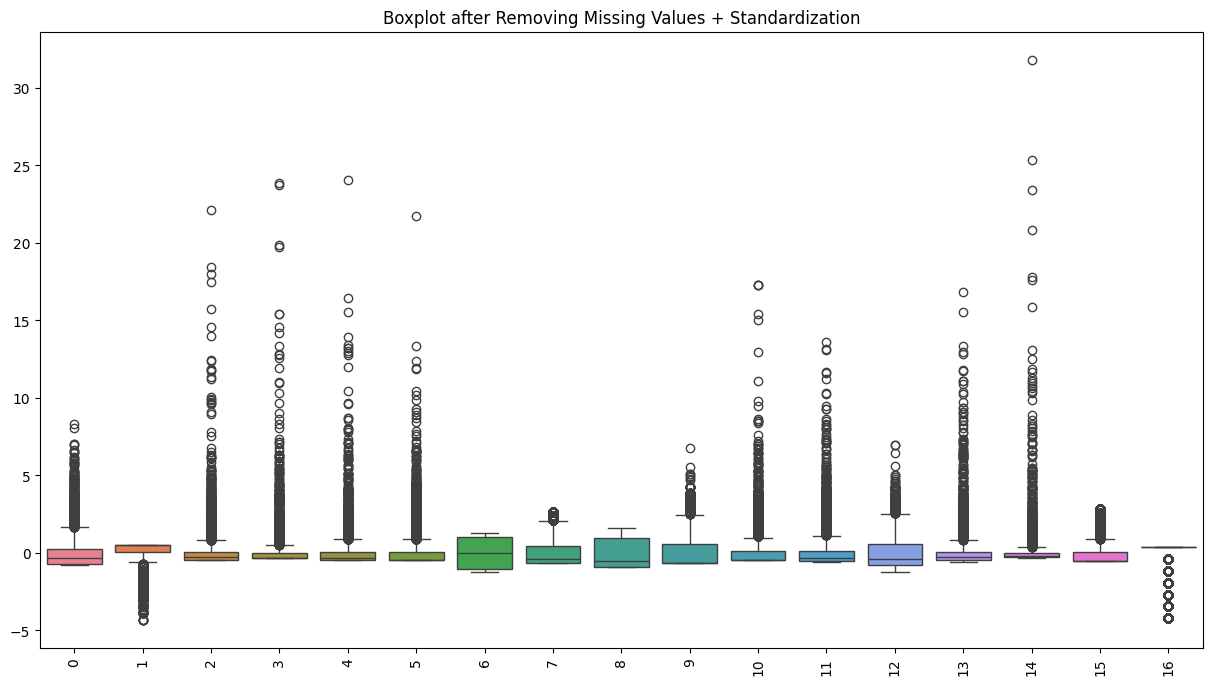

In [21]:
plt.figure(figsize=(15,8))
sns.boxplot(data=d1)
plt.xticks(rotation=90)
plt.title("Boxplot after Removing Missing Values + Standardization")
plt.show()

In [22]:
def kmeans_objective(X,Centroids,distance_lambda):
    #X = number of sample x feature dimension
    #Centroids = number of clusters x feature dimension
    row,col = X.shape
    n_centroids = Centroids.shape[0]

    #Distances = number of samples x number of clusters/centroids
    Distances = np.zeros((row,n_centroids))

    for i in range(row):
        for j in range(n_centroids):
            Distances[i][j] = distance_lambda(X[i],Centroids[j])
    
    #Assignments = number of samples x  (the index of centroid)
    AssignmentsVector = np.argmin(Distances,axis=1)

    #Distance_from_centroid - number of samples x 1 (Distance from nearest centroid)
    DistancesFromNearestCentroid = np.zeros((row,1))
    for i in range(row):
        DistancesFromNearestCentroid[i] = Distances[i][AssignmentsVector[i]]
    
    total = np.sum(DistancesFromNearestCentroid)

    return total,AssignmentsVector

In [23]:
def update_centroids(X,Centroids):
    # X = number of samples x (feature dimension + 1 (cluster_index column at the end))
    # Centroids = number of clusters x feature_dimension
    k, n_features = Centroids.shape
    CentroidsNew = np.zeros((k,n_features))

    for i in range(k):
        #ClusterPoints = number of filtered samples x feature dimension
        ClusterPoints = X[X[:, -1] == i, :-1]

        if ClusterPoints.shape[0] > 0:
            CentroidsNew[i] = np.mean(ClusterPoints, axis=0)
        else:
            CentroidsNew[i] = Centroids[i]

    return CentroidsNew

In [24]:
def event_loop(
    X,
    Centroids,
    distance_lambda,
    convergence_lambda,
    pre_event_lambda=None,
    post_event_lambda=None,
    max_iters=100
):
    #X = number of samples x feature dimension
    #Centroid = number of clusters x feature dimension




    CentroidsPrev = Centroids.copy()

    for iteration in range(max_iters):

        objective_value, Assignments = kmeans_objective(
            X, Centroids, distance_lambda
        )

        if pre_event_lambda is not None:
            pre_event_lambda(X, Centroids, Assignments, objective_value, iteration)

        X_aug = np.hstack((X, Assignments.reshape(-1, 1)))


        CentroidsNew = update_centroids(X_aug, Centroids)


        if post_event_lambda is not None:
            post_event_lambda(X, CentroidsNew, iteration)

        # --- Convergence check ---
        if convergence_lambda(CentroidsPrev, CentroidsNew, iteration):
            Centroids = CentroidsNew
            break

        CentroidsPrev = Centroids
        Centroids = CentroidsNew

    return Centroids, Assignments


In [25]:
distance_lambda = lambda x, c: np.sum((x - c) ** 2)

def centroid_convergence(distance_lambda,threshold=1e-3):
    def convergence_lambda(prev, new, iteration):
        k = prev.shape[0]
        movement = 0.0 
        for i in range(k):
            movement+=distance_lambda(prev[i],new[i])
        # print(f"Iter {iteration}: centroid movement = {movement}")
        return movement < threshold
    return convergence_lambda


In [26]:
def history_collector():
    history = {
        "objectives": [],
        "Centroids": [],
        "Assignments":[],
        "iteration": 0
    }
    def update(X, Centroids, Assignments, objective_value, iteration):
        history["objectives"].append(objective_value)
        history["Centroids"].append(Centroids.copy())
        history["Assignments"].append(Assignments.copy())
        history["iteration"] = history["iteration"]+1

    return history,update

In [27]:
def kmeans_plus_plus_init(X, k, distance_lambda, random_state=None):
    """
    X : (n_samples, n_features)
    k : number of clusters
    distance_lambda : distance function
    random_state : optional int for reproducibility
    """

    if random_state is not None:
        np.random.seed(random_state)

    n_samples = X.shape[0]
    centroids = []

    #Choose first centroid randomly
    first_idx = np.random.choice(n_samples)
    centroids.append(X[first_idx])

    #Choose remaining centroids
    for _ in range(1, k):
        # Compute distance to nearest existing centroid
        distances = np.array([
            min(distance_lambda(x, c) for c in centroids)
            for x in X
        ])

        # Square distances (important!)
        probs = distances ** 2
        probs_sum = probs.sum()

        # Numerical safety
        if probs_sum == 0:
            next_idx = np.random.choice(n_samples)
        else:
            probs /= probs_sum
            next_idx = np.random.choice(n_samples, p=probs)

        centroids.append(X[next_idx])

    return np.array(centroids)


In [28]:
def run_kmeans_for_k(X, k, distance_lambda):
    # Initialize with k-means++
    Centroids = kmeans_plus_plus_init(X, k, distance_lambda)

    history, update_hook = history_collector()

    CentroidFinal, AssignmentsFinal = event_loop(
        X=X,
        Centroids=Centroids,
        distance_lambda=distance_lambda,
        convergence_lambda=centroid_convergence(distance_lambda),
        pre_event_lambda=update_hook,
        max_iters=50
    )

    final_objective = history["objectives"][-1]

    return final_objective, CentroidFinal, AssignmentsFinal, history

In [29]:
def compute_pij(X, centroids, beta):

    # Step 1: compute squared distances
    # D[i, j] = ||x_i - theta_j||^2
    X_sq = np.sum(X**2, axis=1, keepdims=True)       # (n, 1)
    C_sq = np.sum(centroids**2, axis=1)              # (k,)
    D = X_sq + C_sq - 2 * X @ centroids.T            # (n, k)

    # Step 2: apply -beta * D
    logits = -beta * D

    # Step 3: numerical stability (row-wise)
    logits = logits - np.max(logits, axis=1, keepdims=True)

    # Step 4: softmax
    exp_logits = np.exp(logits)
    P = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    return P

In [30]:
def compute_pij(X, centroids, beta):

    X_sq = np.sum(X**2, axis=1, keepdims=True)      # (n, 1)
    C_sq = np.sum(centroids**2, axis=1)             # (k,)
    D = X_sq + C_sq - 2 * X @ centroids.T           # (n, k)

    logits = -beta * D

    # numerical stability
    logits = logits - np.max(logits, axis=1, keepdims=True)

    exp_logits = np.exp(logits)
    P = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

    return P

def compute_entropy(P):
    # avoid log(0)
    eps = 1e-12
    P_safe = np.clip(P, eps, 1.0)
    Hi = -np.sum(P_safe * np.log(P_safe), axis=1)   
    H = np.mean(Hi)

    return Hi, H

In [31]:
def objective_beta(beta, X, centroids, k):
    # Compute P_ij
    P = compute_pij(d1, centroids, beta)

    # Compute entropy
    Hi, Hk = compute_entropy(P)

    # Normalize entropy
    Hk_norm = Hk / np.log(k)

    return Hk_norm


In [32]:
def simulated_annealing_beta(X, centroids, k,
                             beta_init=0.1,
                             T_init=1.0,
                             alpha=0.95,
                             n_iter=100):

    beta = beta_init
    best_beta = beta
    best_score = objective_beta(beta, X, centroids, k)

    T = T_init

    for _ in range(n_iter):
    
        beta_new = beta + np.random.normal(0, 0.5)
        beta_new = max(beta_new, 1e-6)  

        score_new = objective_beta(beta_new, X, centroids, k)

        delta = score_new - best_score

        if delta < 0 or np.random.rand() < np.exp(-delta / T):
            beta = beta_new

            if score_new < best_score:
                best_score = score_new
                best_beta = beta

        T *= alpha

    return best_beta, best_score

In [33]:
k_values = range(2, 30)
objectives = []
results = {}

scores = []
beta = 0.1  # you can tune this
alpha = 0.5



for k in k_values:
    obj, C_final, A_final, hist = run_kmeans_for_k(d1, k, distance_lambda)

    objectives.append(obj)

    results[k] = {
        "centroids": C_final,
        "assignments": A_final,
        "history": hist
    }

    beta_opt, score = simulated_annealing_beta(d1, C_final, k)
    results[k]["best_beta"]=beta_opt
    results[k]["score"]=score
    scores.append(score)


    




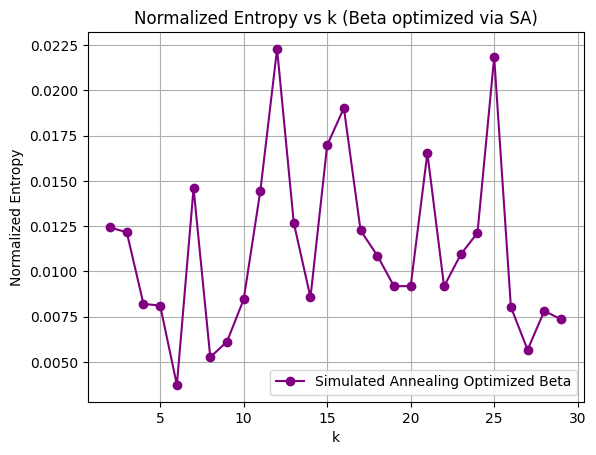

In [44]:
plt.figure()
plt.plot(k_values, scores,color="purple", marker='o', label='Simulated Annealing Optimized Beta')
plt.xlabel("k")
plt.ylabel("Normalized Entropy")
plt.title("Normalized Entropy vs k (Beta optimized via SA)")
plt.grid(True)
plt.legend()
plt.show()

In [45]:
f = []

for k in results:
    beta = results[k]["best_beta"]
    score = results[k]["score"]
    f.append((k, beta, score))

f1 = sorted(f, key=lambda x: x[2])
N = 10
b1 = [item[1] for item in f1[:N]]



In [50]:
curves = []
for beta in b1:
    curve = []
    for k in k_values:
        centroids = results[k]["centroids"]

        P = compute_pij(d1, centroids, beta)
        Hi, Hk = compute_entropy(P)

        e_k = Hk / np.log(k)
        curve.append(e_k)

    curves.append(curve)

median_entropy = np.median(curves, axis=0)


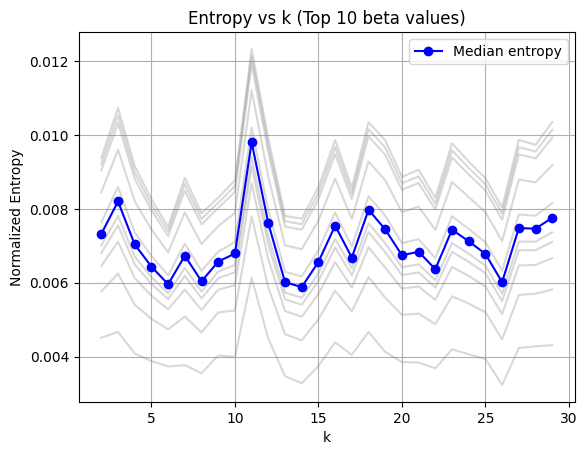

In [51]:
plt.figure()

# Individual curves (light)
for curve in curves:
    plt.plot(k_values, curve, color='gray', alpha=0.3)

# Mean curve (highlight)
plt.plot(k_values, median_entropy, marker='o', color='blue', label='Median entropy')

plt.xlabel("k")
plt.ylabel("Normalized Entropy")
plt.title(f"Entropy vs k (Top {N} beta values)")
plt.legend()
plt.grid(True)
plt.show()